# Experimentation + Uplift Modeling

End-to-end experimentation project with **four serious modeling tracks** (LazyPredict, Manual Engineering, FLAML, PyCaret), unified ranking, ship/no-ship decisioning, and deployment considerations.

## 1) Business Problem and Success Criteria

We are deciding whether to ship treatment `B` in an A/B experiment.

Success criteria:
- Statistical: positive and significant treatment lift in conversion
- Causal targeting: strong uplift ranking quality (AUUC primary, Qini secondary, uplift@top-decile tertiary)
- Operational: acceptable train/inference cost and model artifact size
- Business: targeted policy should be compared against blanket rollout for expected incremental value

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

project_root = Path.cwd()
if str(project_root / 'src') not in sys.path:
    sys.path.append(str(project_root / 'src'))

from ab_test import estimate_ab_test, randomization_diagnostics, power_and_sample_size_check
from uplift import (
    load_raw_dataset,
    load_experiment_data,
    data_dictionary,
    detect_leakage_columns,
    get_feature_columns,
    treatment_control_balance_check,
    split_train_valid_holdout,
    run_lazypredict_discovery_lab,
    run_lazy_top_family_prototypes,
    run_manual_engineering_lab,
    run_flaml_optimization_lab,
    run_pycaret_experiment_lab,
    build_logistic_baseline_row,
    build_unified_leaderboard,
    save_unified_leaderboard,
    simulate_policies,
    decision_recommendation,
    save_t_learner_artifact,
    rerun_candidates_multiple_seeds,
)

RANDOM_SEED = 42
CONVERSION_VALUE = 120.0
np.random.seed(RANDOM_SEED)
pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

## 2) Dataset Access and Data Dictionary

In [2]:
raw_df = load_raw_dataset(project_root)
curated_df, data_source = load_experiment_data(project_root, random_state=RANDOM_SEED)

print(f'Data source: {data_source}')
print(f'Raw rows: {len(raw_df):,} | Curated rows: {len(curated_df):,}')
print(f'Curated columns: {len(curated_df.columns)}')

display(data_dictionary(raw_df).head(20))

Data source: kaggle: storytellerman/pharma-ab-test-packaging-impact-in-mobile-app
Raw rows: 1,000 | Curated rows: 1,000
Curated columns: 18


,column,dtype,n_missing,missing_pct,n_unique,sample_values
0,added_to_cart,int64,0,0.0,2,"1, 0, 1"
1,age_group,str,0,0.0,5,"45–54, 45–54, 45–54"
2,converted,int64,0,0.0,2,"0, 0, 0"
3,device_type,str,0,0.0,2,"Android, iOS, iOS"
4,gender,str,0,0.0,2,"M, F, F"
5,group,str,0,0.0,2,"A, B, B"
6,pack_color,str,0,0.0,2,"Red, Blue, Blue"
7,previous_app_user,int64,0,0.0,2,"1, 1, 1"
8,previous_product_buyer,int64,0,0.0,2,"0, 0, 0"
9,purchase_datetime,str,794,79.4,205,"2024-11-26 16:11, 2024-11-03 07:06, 2024-11-27..."


## 3) Data Cleaning and Leakage Checks

In [3]:
missing_pct = (curated_df.isna().mean() * 100).sort_values(ascending=False).rename('missing_pct')
duplicates = int(curated_df['user_id'].duplicated().sum())

leakage_report = detect_leakage_columns(list(raw_df.columns))
numeric_cov = [c for c in curated_df.columns if pd.api.types.is_numeric_dtype(curated_df[c]) and c not in ['treatment', 'converted']]
cat_cov = [c for c in curated_df.columns if curated_df[c].dtype == 'object']
rand_diag = randomization_diagnostics(curated_df, 'treatment', numeric_cols=numeric_cov, categorical_cols=cat_cov)
balance_smd = treatment_control_balance_check(curated_df, 'treatment', [c for c in curated_df.columns if c not in ['user_id','converted','revenue']])

print(f'Duplicate user IDs: {duplicates}')
print('Top missingness:')
display(missing_pct.head(15).to_frame())
print('Potential leakage columns in raw source:')
display(leakage_report[leakage_report['is_potential_leakage']].reset_index(drop=True))
print('Randomization diagnostics:')
display(rand_diag.head(20))
print('Top standardized mean differences (balance check):')
display(balance_smd.head(20))

Duplicate user IDs: 0
Top missingness:


,missing_pct
user_id,0.0
treatment,0.0
visit_hour_cos,0.0
visit_hour_sin,0.0
is_ios,0.0
is_weekend,0.0
age_group_code,0.0
user_type,0.0
visit_hour,0.0
visit_weekday,0.0


Potential leakage columns in raw source:


,column,is_potential_leakage,reason
0,purchase_datetime,True,post-treatment behavioral signal
1,time_on_page_sec,True,post-treatment behavioral signal
2,scrolled_to_reviews,True,post-treatment behavioral signal
3,added_to_cart,True,post-treatment behavioral signal


Randomization diagnostics:


,feature,test,control_mean,treatment_mean,difference,p_value
1,revenue,welch_ttest,7.512579,11.426876,3.914298,0.002780
0,user_id,welch_ttest,511.266145,489.249489,-22.016656,0.228002
5,age_group_code,welch_ttest,3.062622,2.971370,-0.091252,0.313379
4,visit_hour,welch_ttest,11.819961,12.239264,0.419303,0.327311
8,visit_hour_sin,welch_ttest,-0.033906,-0.072510,-0.038604,0.401236
7,is_ios,welch_ttest,0.487280,0.507157,0.019878,0.530190
10,returning_ios,welch_ttest,0.291585,0.304703,0.013118,0.650754
9,visit_hour_cos,welch_ttest,-0.033061,-0.015613,0.017447,0.687568
6,is_weekend,welch_ttest,0.307241,0.296524,-0.010717,0.712409
2,previous_app_user,welch_ttest,0.612524,0.605317,-0.007207,0.815626


Top standardized mean differences (balance check):


,feature,treated_mean,control_mean,std_mean_diff
0,treatment,1.000000,0.000000,31622.776602
1,visit_weekday=Thursday,0.151329,0.119374,0.093512
2,visit_weekday=Wednesday,0.145194,0.119374,0.076267
3,visit_weekday=Tuesday,0.126789,0.150685,-0.069169
4,age_group_code,2.971370,3.062622,-0.063820
5,visit_hour,12.239264,11.819961,0.062011
6,age_group=45-54,0.184049,0.207436,-0.058970
7,age_group=18-24,0.212679,0.189824,0.057028
8,gender=F,0.482618,0.510763,-0.056315
9,gender=M,0.517382,0.489237,0.056315


## 4) Feature Engineering

Total model features: 14
Engineered features: ['age_group_code', 'is_weekend', 'is_ios', 'visit_hour_sin', 'visit_hour_cos', 'returning_ios']


,age_group,gender,device_type,previous_app_user,previous_product_buyer,visit_weekday,visit_hour,user_type,age_group_code,is_weekend,is_ios,visit_hour_sin,visit_hour_cos,returning_ios,treatment,converted
0,45-54,M,Android,1,0,Monday,7,returning,4,0,0,0.965926,-0.258819,0,0,0
1,45-54,F,iOS,1,0,Saturday,20,returning,4,1,1,-0.866025,0.500000,1,1,0
2,45-54,F,iOS,1,0,Friday,14,returning,4,0,1,-0.500000,-0.866025,1,1,0
3,45-54,F,iOS,1,0,Tuesday,8,returning,4,0,1,0.866025,-0.500000,1,0,1
4,18-24,F,iOS,0,0,Friday,3,new,1,0,1,0.707107,0.707107,0,0,0


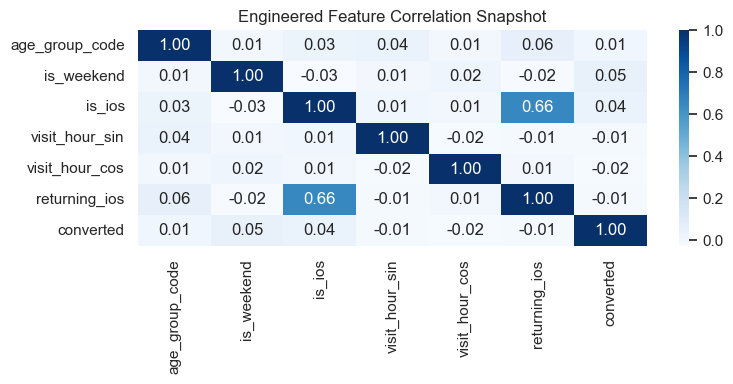

In [4]:
feature_cols = get_feature_columns(curated_df)
engineered_cols = [
    c for c in ['age_group_code','is_weekend','is_ios','visit_hour_sin','visit_hour_cos','returning_ios']
    if c in curated_df.columns
]

print(f'Total model features: {len(feature_cols)}')
print('Engineered features:', engineered_cols)
display(curated_df[feature_cols + ['treatment','converted']].head())

corr_cols = [c for c in engineered_cols if pd.api.types.is_numeric_dtype(curated_df[c])] + ['converted']
if len(corr_cols) > 1:
    plt.figure(figsize=(8, 4))
    sns.heatmap(curated_df[corr_cols].corr(), annot=True, fmt='.2f', cmap='Blues')
    plt.title('Engineered Feature Correlation Snapshot')
    plt.tight_layout()

## 5) Validation Strategy

In [5]:
train_df, valid_df, holdout_df = split_train_valid_holdout(
    curated_df,
    treatment_col='treatment',
    outcome_col='converted',
    valid_size=0.20,
    holdout_size=0.20,
    random_state=RANDOM_SEED,
)

split_summary = pd.DataFrame([
    {'split': 'train', 'rows': len(train_df), 'treatment_rate': train_df['treatment'].mean(), 'conversion_rate': train_df['converted'].mean()},
    {'split': 'valid', 'rows': len(valid_df), 'treatment_rate': valid_df['treatment'].mean(), 'conversion_rate': valid_df['converted'].mean()},
    {'split': 'holdout', 'rows': len(holdout_df), 'treatment_rate': holdout_df['treatment'].mean(), 'conversion_rate': holdout_df['converted'].mean()},
])
display(split_summary)

,split,rows,treatment_rate,conversion_rate
0,train,600,0.488333,0.206667
1,valid,200,0.490000,0.205000
2,holdout,200,0.490000,0.205000


## 6) LazyPredict Discovery Lab

This lab performs rapid model-family discovery on treatment and control arms separately, then merges results to identify uplift-suitable families.

In [6]:
lazy_ranked, lazy_top3, lazy_arm_tables = run_lazypredict_discovery_lab(
    train_df=train_df,
    valid_df=valid_df,
    feature_cols=feature_cols,
    random_state=RANDOM_SEED,
)

print('Top candidate families from LazyPredict discovery:')
print(lazy_top3)
display(lazy_ranked.head(15))

print('Treatment-arm benchmark snapshot:')
display(lazy_arm_tables['treatment_arm'].head(10))
print('Control-arm benchmark snapshot:')
display(lazy_arm_tables['control_arm'].head(10))

Top candidate families from LazyPredict discovery:
['GradientBoostingClassifier', 'RidgeClassifier', 'AdaBoostClassifier']


,model_family,Accuracy_treat,Balanced Accuracy_treat,ROC AUC_treat,F1 Score_treat,Precision_treat,Recall_treat,Time Taken_treat,Accuracy_ctrl,Balanced Accuracy_ctrl,ROC AUC_ctrl,F1 Score_ctrl,Precision_ctrl,Recall_ctrl,Time Taken_ctrl,balanced_accuracy_mean,roc_auc_mean,time_taken_mean
0,GradientBoostingClassifier,0.663265,0.497808,0.455068,0.636083,0.617907,0.663265,0.093613,0.774510,0.510174,0.507994,0.756816,0.741944,0.774510,0.095139,0.503991,0.481531,0.094376
1,RidgeClassifier,0.714286,0.479452,0.400274,0.620748,0.548872,0.714286,0.014698,0.843137,0.500000,0.413517,0.771381,0.710880,0.843137,0.013721,0.489726,0.406896,0.014209
2,AdaBoostClassifier,0.704082,0.472603,0.347123,0.615544,0.546787,0.704082,0.072919,0.843137,0.500000,0.365552,0.771381,0.710880,0.843137,0.074403,0.486301,0.356338,0.073661
3,LGBMClassifier,0.622449,0.457260,0.404658,0.600355,0.582568,0.622449,0.036158,0.784314,0.490552,0.505814,0.753159,0.728202,0.784314,0.028173,0.473906,0.455236,0.032166
4,LogisticRegression,0.663265,0.445205,0.401370,0.594090,0.537982,0.663265,0.015781,0.843137,0.500000,0.413517,0.771381,0.710880,0.843137,0.015313,0.472603,0.407444,0.015547
5,XGBClassifier,0.612245,0.450411,0.405753,0.593460,0.577737,0.612245,2.949655,0.745098,0.492733,0.486919,0.738066,0.731411,0.745098,1.978954,0.471572,0.446336,2.464304
6,RandomForestClassifier,0.683673,0.472055,0.435342,0.618691,0.578146,0.683673,0.123033,0.794118,0.470930,0.508721,0.746384,0.704063,0.794118,0.119710,0.471493,0.472032,0.121372


Treatment-arm benchmark snapshot:


,model_family,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
0,GradientBoostingClassifier,0.663265,0.497808,0.455068,0.636083,0.617907,0.663265,0.093613
1,DecisionTreeClassifier,0.571429,0.488767,0.479452,0.588563,0.611921,0.571429,0.013822
2,RidgeClassifier,0.714286,0.479452,0.400274,0.620748,0.548872,0.714286,0.014698
3,AdaBoostClassifier,0.704082,0.472603,0.347123,0.615544,0.546787,0.704082,0.072919
4,RandomForestClassifier,0.683673,0.472055,0.435342,0.618691,0.578146,0.683673,0.123033
5,LGBMClassifier,0.622449,0.457260,0.404658,0.600355,0.582568,0.622449,0.036158
6,XGBClassifier,0.612245,0.450411,0.405753,0.593460,0.577737,0.612245,2.949655
7,LogisticRegression,0.663265,0.445205,0.401370,0.594090,0.537982,0.663265,0.015781
8,KNeighborsClassifier,0.622449,0.444110,0.465479,0.591972,0.567851,0.622449,0.042992
9,LinearDiscriminantAnalysis,0.653061,0.438356,0.400822,0.588561,0.535657,0.653061,0.013692


Control-arm benchmark snapshot:


,model_family,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
0,GradientBoostingClassifier,0.774510,0.510174,0.507994,0.756816,0.741944,0.774510,0.095139
1,ExtraTreesClassifier,0.764706,0.504360,0.446584,0.750573,0.738126,0.764706,0.099060
2,LogisticRegression,0.843137,0.500000,0.413517,0.771381,0.710880,0.843137,0.015313
3,RidgeClassifier,0.843137,0.500000,0.413517,0.771381,0.710880,0.843137,0.013721
4,AdaBoostClassifier,0.843137,0.500000,0.365552,0.771381,0.710880,0.843137,0.074403
5,LinearDiscriminantAnalysis,0.843137,0.500000,0.414244,0.771381,0.710880,0.843137,0.014172
6,KNeighborsClassifier,0.794118,0.496366,0.451308,0.758955,0.732419,0.794118,0.017785
7,XGBClassifier,0.745098,0.492733,0.486919,0.738066,0.731411,0.745098,1.978954
8,LGBMClassifier,0.784314,0.490552,0.505814,0.753159,0.728202,0.784314,0.028173
9,RandomForestClassifier,0.794118,0.470930,0.508721,0.746384,0.704063,0.794118,0.119710


## 7) Selection of Top 3 Eligible Models

Eligibility rule:
- Ranked by merged arm performance from LazyPredict
- Filtered to avoid weak/unstable families
- Top 3 are the **only** manual engineering candidates

In [7]:
selected_top3 = lazy_top3[:3]
selection_table = lazy_ranked[lazy_ranked['model_family'].isin(selected_top3)][
    ['model_family', 'balanced_accuracy_mean', 'roc_auc_mean', 'time_taken_mean']
].sort_values('balanced_accuracy_mean', ascending=False)

lazy_prototype_rows, lazy_prototype_models = run_lazy_top_family_prototypes(
    top_families=selected_top3,
    train_df=train_df,
    holdout_df=holdout_df,
    feature_cols=feature_cols,
    conversion_value=CONVERSION_VALUE,
    random_state=RANDOM_SEED,
)

display(selection_table)
print('Lazy prototype holdout results (for final unified leaderboard):')
display(lazy_prototype_rows[['model_name','holdout_primary_metric','holdout_secondary_metric','holdout_tertiary_metric','train_time_sec']])

,model_family,balanced_accuracy_mean,roc_auc_mean,time_taken_mean
0,GradientBoostingClassifier,0.503991,0.481531,0.094376
1,RidgeClassifier,0.489726,0.406896,0.014209
2,AdaBoostClassifier,0.486301,0.356338,0.073661


Lazy prototype holdout results (for final unified leaderboard):


,model_name,holdout_primary_metric,holdout_secondary_metric,holdout_tertiary_metric,train_time_sec
0,LazyPrototype T-Learner (GradientBoostingClass...,0.027091,-0.022028,0.408163,0.171752
1,LazyPrototype T-Learner (RidgeClassifier),0.059753,0.010635,0.412165,0.007392
2,LazyPrototype T-Learner (AdaBoostClassifier),0.034393,-0.014725,-0.094038,0.108370


## 8) Manual Engineering Lab

Manual implementations are built only for the selected top-3 model families.
Enhancements in this track:
- explicit preprocessing
- calibrated probabilities
- policy fraction tuning on validation split
- holdout uplift evaluation

In [8]:
manual_rows, manual_models, manual_policy_tables = run_manual_engineering_lab(
    top_families=selected_top3,
    train_df=train_df,
    valid_df=valid_df,
    holdout_df=holdout_df,
    feature_cols=feature_cols,
    conversion_value=CONVERSION_VALUE,
    random_state=RANDOM_SEED,
)

display(manual_rows[['model_name','selected_target_fraction','holdout_primary_metric','holdout_secondary_metric','calibration_metric','train_time_sec']])

for key, table in manual_policy_tables.items():
    print(f'Policy tuning table: {key}')
    display(table.head())

,model_name,selected_target_fraction,holdout_primary_metric,holdout_secondary_metric,calibration_metric,train_time_sec
0,Manual Calibrated T-Learner (GradientBoostingC...,0.5,0.034250,-0.014868,0.164606,0.467206
1,Manual Calibrated T-Learner (RidgeClassifier),0.5,0.058805,0.009687,0.161589,0.035205
2,Manual Calibrated T-Learner (AdaBoostClassifier),0.5,0.041229,-0.007889,0.161225,0.377636


Policy tuning table: manual::GradientBoostingClassifier


,target_fraction,expected_incremental_value_targeted,expected_incremental_conversions_targeted
0,0.5,821.128451,6.842737
1,0.4,566.626651,4.721889
2,0.2,528.211285,4.401761
3,0.3,67.226891,0.560224
4,0.1,19.207683,0.160064


Policy tuning table: manual::RidgeClassifier


,target_fraction,expected_incremental_value_targeted,expected_incremental_conversions_targeted
0,0.5,2036.014406,16.966787
1,0.4,1037.214886,8.643457
2,0.3,773.109244,6.442577
3,0.1,264.105642,2.200880
4,0.2,38.415366,0.320128


Policy tuning table: manual::AdaBoostClassifier


,target_fraction,expected_incremental_value_targeted,expected_incremental_conversions_targeted
0,0.5,821.128451,6.842737
1,0.3,782.713085,6.522609
2,0.4,321.728691,2.681072
3,0.2,38.415366,0.320128
4,0.1,-460.984394,-3.841537


## 9) FLAML Optimization Lab

FLAML is used as a full optimization track with explicit time budget, CV-driven search, and hyperparameter reporting for treatment/control response models.

In [9]:
flaml_rows, flaml_model, flaml_policy_table, flaml_details = run_flaml_optimization_lab(
    train_df=train_df,
    valid_df=valid_df,
    holdout_df=holdout_df,
    feature_cols=feature_cols,
    conversion_value=CONVERSION_VALUE,
    random_state=RANDOM_SEED,
    time_budget=35,
)

display(flaml_rows[['model_name','selected_target_fraction','holdout_primary_metric','holdout_secondary_metric','train_time_sec']])
display(pd.DataFrame([flaml_details]))
display(flaml_policy_table.head())

,model_name,selected_target_fraction,holdout_primary_metric,holdout_secondary_metric,train_time_sec
0,FLAML Optimized T-Learner,0.5,0.029826,-0.019292,72.540747


,treatment_best_estimator,control_best_estimator,treatment_best_config,control_best_config,treatment_best_loss,control_best_loss,time_budget_per_arm_sec
0,xgboost,lgbm,"{'n_estimators': 4, 'max_leaves': 16, 'min_chi...","{'n_estimators': 7, 'num_leaves': 19, 'min_chi...",0.552843,0.444465,35


,target_fraction,expected_incremental_value_targeted,expected_incremental_conversions_targeted
0,0.5,811.524610,6.762705
1,0.4,321.728691,2.681072
2,0.3,67.226891,0.560224
3,0.2,-677.070828,-5.642257
4,0.1,-1166.866747,-9.723890


## 10) PyCaret Experiment Lab

PyCaret is treated as a full experiment-orchestration track:
- fit/setup via experiment object
- compare_models
- tune_model
- calibrate_model
- finalize_model
- save_model

In [10]:
pycaret_rows, pycaret_model, pycaret_policy_table, pycaret_details = run_pycaret_experiment_lab(
    train_df=train_df,
    valid_df=valid_df,
    holdout_df=holdout_df,
    feature_cols=feature_cols,
    conversion_value=CONVERSION_VALUE,
    random_state=RANDOM_SEED,
)

display(pycaret_rows[['model_name','selected_target_fraction','holdout_primary_metric','holdout_secondary_metric','train_time_sec']])
print('Saved PyCaret treatment model:', pycaret_details['saved_treatment_model'])
print('Saved PyCaret control model:', pycaret_details['saved_control_model'])
print('Treatment compare top:')
display(pycaret_details['treatment_compare_top'])
print('Control compare top:')
display(pycaret_details['control_compare_top'])
print('Treatment tuning result:')
display(pycaret_details['treatment_tune_result'])

,model_name,selected_target_fraction,holdout_primary_metric,holdout_secondary_metric,train_time_sec
0,PyCaret Finalized T-Learner,0.2,0.051795,0.002677,4.710694


Saved PyCaret treatment model: /home/ahmad/AI/Projects/experimentation-uplift-modeling/artifacts/models/treatment_pycaret.pkl
Saved PyCaret control model: /home/ahmad/AI/Projects/experimentation-uplift-modeling/artifacts/models/control_pycaret.pkl
Treatment compare top:


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,xgboost,0.6295,0.4987,0.0577,0.1090,0.0748,-0.1356,-0.1424
1,lightgbm,0.7026,0.4625,0.0959,0.2741,0.1403,0.0067,0.0103
2,lr,0.7317,0.4287,0.0185,0.1111,0.0317,-0.0116,-0.0353
3,rf,0.6930,0.4078,0.0196,0.0833,0.0317,-0.0755,-0.1000
4,et,0.6687,0.4031,0.0196,0.0833,0.0317,-0.1114,-0.1296


Control compare top:


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,lr,0.8271,0.5860,0.0278,0.1111,0.0444,0.0149,0.0131
1,et,0.8085,0.5818,0.0833,0.1619,0.1094,0.0401,0.0425
2,rf,0.8177,0.5601,0.0833,0.2000,0.1176,0.0575,0.0646
3,lightgbm,0.7946,0.5539,0.0833,0.1333,0.0998,0.0187,0.0196
4,xgboost,0.7573,0.5320,0.1136,0.2004,0.1322,0.0033,0.0101


Treatment tuning result:


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold 0,0.5072,0.4542,0.2222,0.1667,0.1905,-0.1534,-0.1567
Fold 1,0.6471,0.6286,0.4118,0.3333,0.3684,0.1273,0.1286
Fold 2,0.6324,0.5825,0.4118,0.3182,0.3590,0.1071,0.1089
Mean,0.5956,0.5551,0.3486,0.2727,0.3060,0.0270,0.0270
Std,0.0627,0.0738,0.0894,0.0753,0.0817,0.1278,0.1301


## 11) Unified Leaderboard and Final Model Ranking

Final leaderboard includes:
- top LazyPredict prototype results
- manual engineered top-3
- FLAML best optimized candidate
- PyCaret finalized candidate
- baseline model

In [11]:
baseline_rows, baseline_model = build_logistic_baseline_row(
    train_df=train_df,
    holdout_df=holdout_df,
    feature_cols=feature_cols,
    random_state=RANDOM_SEED,
)

all_rows = pd.concat([
    baseline_rows,
    lazy_prototype_rows,
    manual_rows,
    flaml_rows,
    pycaret_rows,
], ignore_index=True)

leaderboard = build_unified_leaderboard(all_rows)
leaderboard_path = save_unified_leaderboard(leaderboard, project_root / 'artifacts' / 'leaderboard_uplift.csv')
print('Saved unified leaderboard to:', leaderboard_path)
display(leaderboard.head(10))

model_registry = {
    **{k: v for k, v in lazy_prototype_models.items()},
    **{k: v for k, v in manual_models.items()},
    'flaml::t_learner': flaml_model,
    'pycaret::t_learner': pycaret_model,
    'baseline::logistic': baseline_model,
}

top3_candidate_keys = leaderboard.head(3)['candidate_key'].tolist()
seed_stability = rerun_candidates_multiple_seeds(
    df=curated_df,
    feature_cols=feature_cols,
    candidate_keys=top3_candidate_keys,
    seeds=[11, 42, 73],
)
seed_stability_path = project_root / 'artifacts' / 'top3_seed_stability.csv'
seed_stability.to_csv(seed_stability_path, index=False)
print('Saved multi-seed top-3 stability to:', seed_stability_path)
display(seed_stability)

Saved unified leaderboard to: /home/ahmad/AI/Projects/experimentation-uplift-modeling/artifacts/leaderboard_uplift.csv


,project_name,task_type,library_source,model_name,cv_metric_mean,cv_metric_std,holdout_primary_metric,holdout_secondary_metric,holdout_tertiary_metric,calibration_metric,train_time_sec,infer_latency_ms,model_size_mb,interpretability_note,rank_score,final_rank,candidate_key,selected_target_fraction,policy_incremental_value
0,experimentation-uplift-modeling,uplift_modeling,baseline,Baseline Logistic T-Learner,0.055903,0.038332,0.061028,0.011909,0.408163,0.168281,0.062955,0.024949,0.004327,High: transparent baseline for uplift effect r...,0.976614,1,baseline::logistic,0.3,1027.611044
1,experimentation-uplift-modeling,uplift_modeling,lazypredict,LazyPrototype T-Learner (RidgeClassifier),0.060521,0.037378,0.059753,0.010635,0.412165,0.185391,0.007392,0.026971,0.004342,Discovery-only prototype from LazyPredict fami...,0.903223,2,lazy_proto::RidgeClassifier,0.3,792.316927
2,experimentation-uplift-modeling,uplift_modeling,manual,Manual Calibrated T-Learner (RidgeClassifier),0.060925,0.034445,0.058805,0.009687,0.106042,0.161589,0.035205,0.034942,0.007367,High: calibrated two-model uplift with manual ...,0.887415,3,manual::RidgeClassifier,0.5,1536.614646
3,experimentation-uplift-modeling,uplift_modeling,pycaret,PyCaret Finalized T-Learner,0.045880,0.033796,0.051795,0.002677,0.306122,0.163810,4.710694,0.115012,NaN,"Lower: orchestrated AutoML workflow (compare, ...",0.705091,4,pycaret::t_learner,0.2,499.399760
4,experimentation-uplift-modeling,uplift_modeling,manual,Manual Calibrated T-Learner (AdaBoostClassifier),0.038293,0.035587,0.041229,-0.007889,0.008003,0.161225,0.377636,0.180400,0.165114,High: calibrated two-model uplift with manual ...,0.511473,5,manual::AdaBoostClassifier,0.5,576.230492
5,experimentation-uplift-modeling,uplift_modeling,manual,Manual Calibrated T-Learner (GradientBoostingC...,0.029576,0.039438,0.034250,-0.014868,0.114046,0.164606,0.467206,0.048935,0.771036,High: calibrated two-model uplift with manual ...,0.433227,6,manual::GradientBoostingClassifier,0.5,821.128451
6,experimentation-uplift-modeling,uplift_modeling,lazypredict,LazyPrototype T-Learner (GradientBoostingClass...,0.022689,0.037623,0.027091,-0.022028,0.408163,0.199093,0.171752,0.027219,0.262190,Discovery-only prototype from LazyPredict fami...,0.344114,7,lazy_proto::GradientBoostingClassifier,0.3,-177.671068
7,experimentation-uplift-modeling,uplift_modeling,lazypredict,LazyPrototype T-Learner (AdaBoostClassifier),0.032061,0.035324,0.034393,-0.014725,-0.094038,0.195368,0.108370,0.077576,0.057616,Discovery-only prototype from LazyPredict fami...,0.339454,8,lazy_proto::AdaBoostClassifier,0.3,547.418968
8,experimentation-uplift-modeling,uplift_modeling,flaml,FLAML Optimized T-Learner,0.026250,0.034243,0.029826,-0.019292,0.204082,0.167965,72.540747,0.098589,0.248129,Moderate: AutoML-selected response learners wi...,0.300267,9,flaml::t_learner,0.5,-168.067227


Saved multi-seed top-3 stability to: /home/ahmad/AI/Projects/experimentation-uplift-modeling/artifacts/top3_seed_stability.csv


,candidate_key,auuc_mean,auuc_std,auuc_min,auuc_max,n_runs
0,lazy_proto::RidgeClassifier,0.050166,0.009068,0.041727,0.059753,3
1,baseline::logistic,0.046286,0.013629,0.034144,0.061028,3
2,manual::RidgeClassifier,0.043906,0.018375,0.023373,0.058805,3


## 12) Business Recommendation

In [12]:
ab_result = estimate_ab_test(curated_df, treatment_col='treatment', outcome_col='converted')
power_check = power_and_sample_size_check(
    baseline_rate=ab_result.control_rate,
    observed_lift=ab_result.absolute_lift,
    n_control=ab_result.n_control,
    n_treatment=ab_result.n_treatment,
)

winner = leaderboard.iloc[0]
winner_key = winner['candidate_key']
winner_model = model_registry[winner_key]
winner_scores = winner_model.predict_uplift(holdout_df)
winner_fraction = float(winner.get('selected_target_fraction', 0.30))

policy_eval = simulate_policies(
    y=holdout_df['converted'].to_numpy(dtype=int),
    w=holdout_df['treatment'].to_numpy(dtype=int),
    uplift_score=winner_scores,
    conversion_value=CONVERSION_VALUE,
    top_fraction=winner_fraction,
)

decision = decision_recommendation(
    ab_p_value=ab_result.p_value,
    ab_lift=ab_result.absolute_lift,
    ci_low=ab_result.ci_low,
    ci_high=ab_result.ci_high,
    blanket_value=policy_eval['expected_incremental_value_blanket'],
    targeted_value=policy_eval['expected_incremental_value_targeted'],
)

second_best = leaderboard.iloc[1] if len(leaderboard) > 1 else None
second_best_note = ''
if second_best is not None:
    if second_best['calibration_metric'] < winner['calibration_metric']:
        second_best_note = f"Second-best ({second_best['model_name']}) may be safer if calibration risk dominates."
    elif second_best['infer_latency_ms'] < winner['infer_latency_ms']:
        second_best_note = f"Second-best ({second_best['model_name']}) may be safer for latency-constrained serving."
    else:
        second_best_note = f"Second-best ({second_best['model_name']}) is a fallback if operational constraints change."

ab_df = pd.DataFrame([ab_result.__dict__])
power_df = pd.DataFrame([power_check.__dict__])
decision_df = pd.DataFrame([decision])
policy_df = pd.DataFrame([policy_eval])

display(ab_df)
display(power_df)
display(policy_df)
display(decision_df)
print('Winner candidate key:', winner_key)
print('Second-best note:', second_best_note)

,n_control,n_treatment,control_rate,treatment_rate,absolute_lift,relative_lift,ci_low,ci_high,p_value
0,511,489,0.16047,0.253579,0.093109,0.580228,0.043112,0.143106,0.000273


,baseline_rate,observed_lift,alpha,target_power,required_n_per_group,observed_power,is_sample_adequate
0,0.16047,0.093109,0.05,0.8,294,0.946748,True


,expected_incremental_conversions_blanket,expected_incremental_conversions_targeted,expected_incremental_value_blanket,expected_incremental_value_targeted,target_fraction
0,19.647859,8.563425,2357.743097,1027.611044,0.3


,decision,rationale,ab_ci,expected_incremental_value_blanket,expected_incremental_value_targeted
0,ship_all,"A/B effect is positive and reliable, with limi...","[0.0431, 0.1431]",2357.743097,1027.611044


Winner candidate key: baseline::logistic
Second-best note: Second-best (LazyPrototype T-Learner (RidgeClassifier)) is a fallback if operational constraints change.


## 13) Inference / Deployment Path

In [13]:
deployment_dir = project_root / 'artifacts' / 'models'
deployment_dir.mkdir(parents=True, exist_ok=True)

winner_artifact_path = deployment_dir / 'winner_t_learner.pkl'
artifact_status = 'saved'
try:
    save_t_learner_artifact(winner_model, winner_artifact_path)
except Exception as exc:
    artifact_status = f'not_saved: {type(exc).__name__}: {exc}'

inference_example = holdout_df[feature_cols].head(5).copy()
inference_scores = winner_model.predict_uplift(holdout_df.head(5))
inference_output = inference_example.copy()
inference_output['predicted_uplift'] = inference_scores

print('Winner artifact path:', winner_artifact_path)
print('Artifact status:', artifact_status)
display(inference_output)

Winner artifact path: /home/ahmad/AI/Projects/experimentation-uplift-modeling/artifacts/models/winner_t_learner.pkl
Artifact status: saved


,age_group,gender,device_type,previous_app_user,previous_product_buyer,visit_weekday,visit_hour,user_type,age_group_code,is_weekend,is_ios,visit_hour_sin,visit_hour_cos,returning_ios,predicted_uplift
0,55+,F,iOS,0,0,Friday,15,new,5,0,1,-0.707107,-7.071068e-01,0,0.117285
1,35-44,M,iOS,1,0,Friday,9,returning,3,0,1,0.707107,-7.071068e-01,1,0.135459
2,45-54,M,Android,1,1,Monday,15,returning,4,0,0,-0.707107,-7.071068e-01,0,-0.159053
3,25-34,M,Android,0,0,Saturday,18,new,2,1,0,-1.000000,-1.836970e-16,0,0.165970
4,25-34,M,Android,1,0,Friday,9,returning,2,0,0,0.707107,-7.071068e-01,0,0.276521


## 14) Monitoring / Drift / Retraining Plan

Production monitoring plan:
- Track global and segment conversion lift vs experiment baseline
- Monitor policy value realized vs simulated (`ship_all` and targeted shadow policy)
- Watch calibration drift (Brier) and uplift ranking drift (AUUC/Qini on refreshed labels)
- Data drift checks on `device_type`, `user_type`, `age_group`, and engineered features
- Retraining triggers:
  - AUUC drop > 10% from validation baseline
  - Calibration metric degradation > 20%
  - Material traffic mix shift in top decile segments
- Cadence: monthly shadow evaluation, quarterly full retrain or event-triggered retrain

## 15) Limitations and Next Steps

Limitations:
- Single historical A/B dataset and moderate sample size
- Offline policy simulation (IPS-style) may diverge from online impact
- PyCaret 4 pre-release API introduces library-level volatility

Next steps:
1. Run online policy A/B to validate targeted policy lift vs blanket rollout
2. Add confidence intervals for policy value and segment-level uplift uncertainty
3. Add model cards and automated retraining pipeline orchestration